# 📈 SARIMA: Pronóstico de Producción (Serie Completa)

**Objetivo:** Generar el pronóstico operativo final para el recaudo de Rentas Cedidas en Quibdó, utilizando la totalidad de la información histórica disponible (2021-2025).

---

## Diferencia con el Benchmark
A diferencia del cuaderno `04_SARIMA.ipynb`, este archivo **no realiza partición temporal** (train/test). Su propósito es maximizar el aprendizaje del modelo sobre los datos más recientes para proyectar los próximos 12 meses con la mayor precisión estadística posible.

In [1]:
# === CONFIGURACIÓN ===
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '../scripts')
%run 00_config.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.statespace.sarimax import SARIMAX
from utils import cargar_datos, agregar_mensual

try:
    import pmdarima as pm
    HAS_PMDARIMA = True
except:
    HAS_PMDARIMA = False

if _VIZ_THEME_LOADED:
    aplicar_tema_profesional()
    print('🎨 Tema profesional activo')

  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


✅ Config cargada — Datos: BaseRentasVF_2022_2025.xlsx | Periodo: 2022-01-01 a 2025-12-31
  🎨 Tema profesional activo — DPI 300, tipografía serif, paleta académica


🎨 Tema profesional activo


## 1. Carga de Datos
Cargamos la serie mensual completa procesada.

In [2]:
try:
    df_mensual = pd.read_csv(DATA_PROCESSED / 'serie_mensual.csv', index_col=0, parse_dates=True)
except FileNotFoundError:
    df = cargar_datos(DATA_FILE)
    df_mensual = agregar_mensual(df)

y_full = df_mensual[COL_RECAUDO_NETO]
print(f'📂 Datos cargados: {len(y_full)} meses ({y_full.index[0]:%Y-%m} a {y_full.index[-1]:%Y-%m})')

📂 Datos cargados: 48 meses (2022-01 a 2025-12)


## 2. Selección del Mejor Modelo (Full Data)
Buscamos el orden óptimo utilizando el criterio AIC sobre toda la serie.

In [3]:
if HAS_PMDARIMA:
    print('🔍 Buscando mejor orden SARIMA...')
    auto_model = pm.auto_arima(
        y_full, seasonal=True, m=ESTACIONALIDAD,
        stepwise=True, suppress_warnings=True,
        trace=True
    )
    order = auto_model.order
    seasonal_order = auto_model.seasonal_order
else:
    order = (1, 1, 1)
    seasonal_order = (1, 1, 1, ESTACIONALIDAD)

print(f'\n✅ Modelo Final Seleccionado: SARIMA{order}x{seasonal_order}')

🔍 Buscando mejor orden SARIMA...
Performing stepwise search to minimize aic


 ARIMA(2,0,2)(1,1,1)[12] intercept   : AIC=1863.772, Time=0.30 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1856.213, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1860.108, Time=0.06 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1860.517, Time=0.05 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1862.765, Time=0.01 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=1858.192, Time=0.03 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1858.188, Time=0.03 sec


 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=1860.163, Time=0.07 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1858.293, Time=0.01 sec
 ARIMA(0,0,1)(0,1,0)[12] intercept   : AIC=1858.536, Time=0.02 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=1860.464, Time=0.03 sec

Best model:  ARIMA(0,0,0)(0,1,0)[12] intercept
Total fit time: 0.637 seconds

✅ Modelo Final Seleccionado: SARIMA(0, 0, 0)x(0, 1, 0, 12)


## 3. Entrenamiento y Pronóstico
Ajustamos el modelo final y proyectamos los próximos 12 meses.

In [4]:
modelo = SARIMAX(y_full, order=order, seasonal_order=seasonal_order)
resultado = modelo.fit(disp=False, maxiter=500)

# Pronóstico a 12 meses (Planeación Anual)
HORIZONTE_FINAL = 12
forecast = resultado.get_forecast(steps=HORIZONTE_FINAL)
y_pred = forecast.predicted_mean
ci = forecast.conf_int(alpha=0.05)

print(f'📈 Pronóstico generado para los próximos {HORIZONTE_FINAL} meses')

📈 Pronóstico generado para los próximos 12 meses


## 4. Visualización Final

  📊 Figura guardada: sarima_produccion_final.png.png


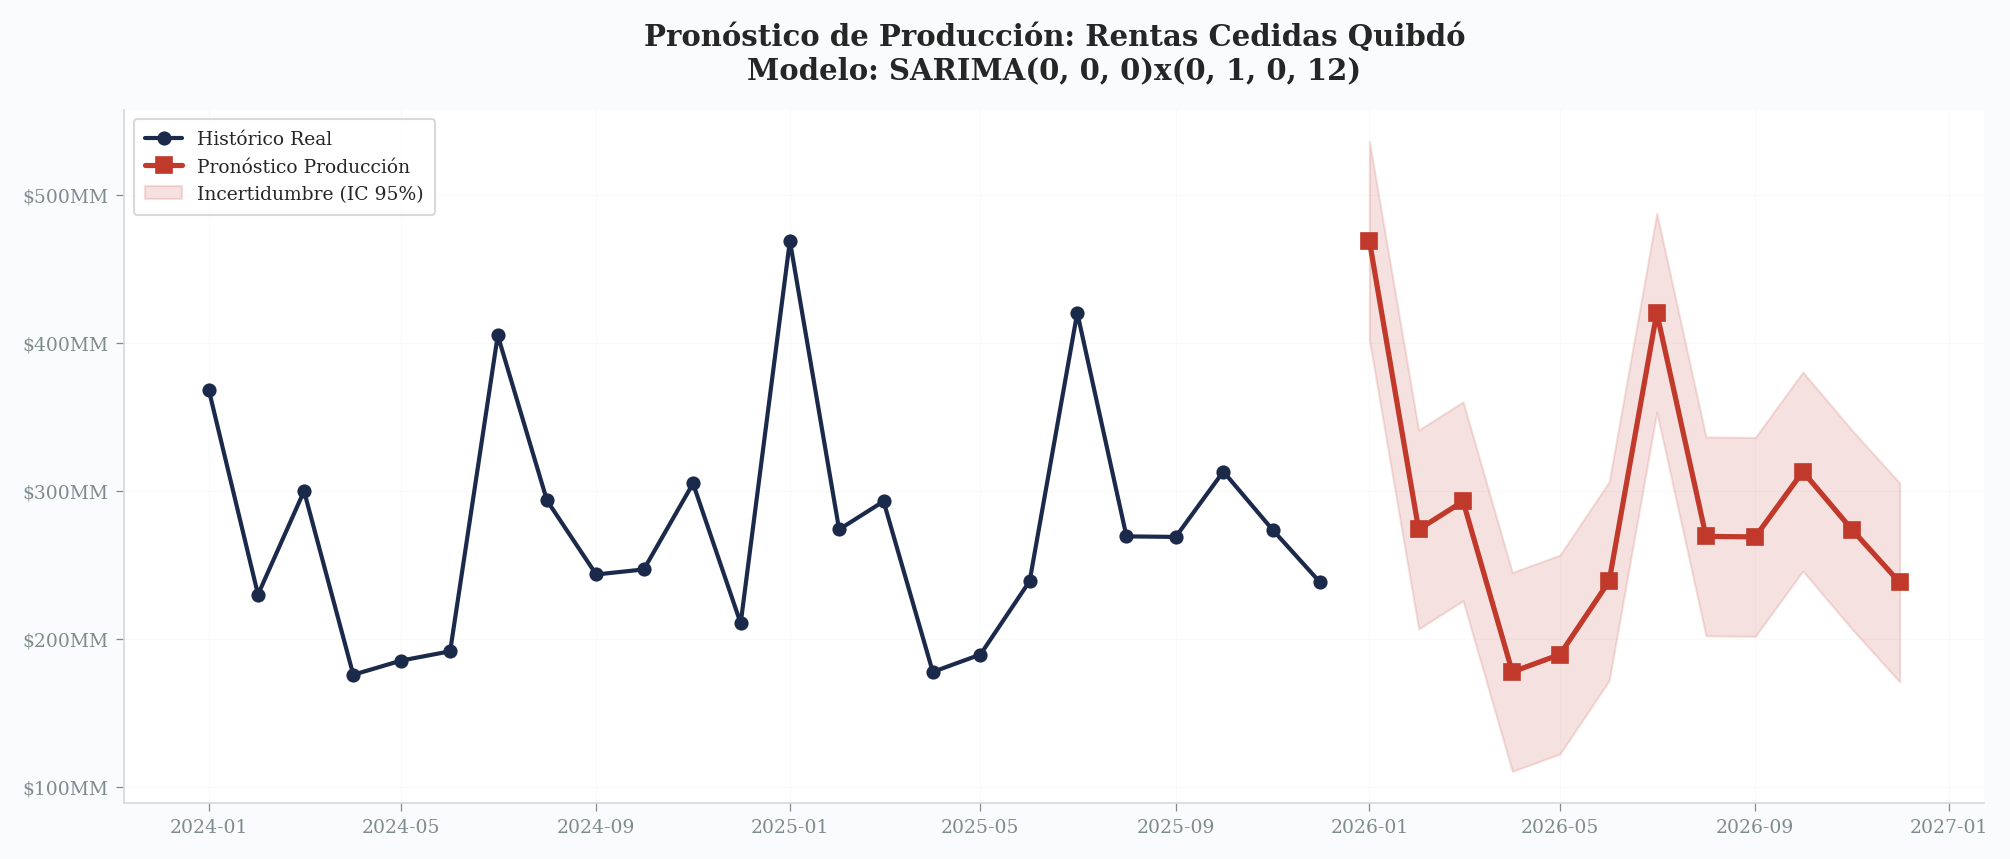

In [5]:
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)

# Histórico reciente (24 meses)
ax.plot(y_full.iloc[-24:].index, y_full.iloc[-24:].values, 'o-', 
        color=COLORES['real'], label='Histórico Real')

# Pronóstico futuro
ax.plot(y_pred.index, y_pred.values, 's-', color=COLORES['sarima'], 
        linewidth=2.5, markersize=8, label='Pronóstico Producción')

# Banda de confianza
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], 
                color=COLORES['sarima'], alpha=0.15, label='Incertidumbre (IC 95%)')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(formato_pesos))
ax.set_title(f'Pronóstico de Producción: Rentas Cedidas Quibdó\nModelo: SARIMA{order}x{seasonal_order}', 
             fontweight='bold', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

guardar_figura(fig, 'sarima_produccion_final.png')
plt.show()

## 5. Exportación de Resultados
Guardamos los resultados en la carpeta de salidas.

In [6]:
df_final = pd.DataFrame({
    'Pronostico': y_pred.values,
    'Limite_Inferior': ci.iloc[:, 0].values,
    'Limite_Superior': ci.iloc[:, 1].values
}, index=y_pred.index)

df_final.to_csv(OUTPUTS_FORECASTS / 'sarima_produccion_12m.csv')
print(f'✅ Resultados exportados a: {OUTPUTS_FORECASTS / "sarima_produccion_12m.csv"}')

✅ Resultados exportados a: C:\Users\efren\Music\ESTRUCTURA DATOS RENTAS\outputs\forecasts\sarima_produccion_12m.csv


## 5. Validación de Cierre 2025 y Precisión del Modelo
Para validar la confianza en el pronóstico de 2026, comparamos el **Recaudo Real** del último trimestre de 2025 contra el **Pronóstico Ajustado (In-sample)** del modelo.

In [7]:
# 1. Obtener predicciones in-sample (ajustadas) para el cierre 2025
pred_in_sample = resultado.get_prediction(start=y_full.index[-3], end=y_full.index[-1])
y_pred_q4 = pred_in_sample.predicted_mean

# 2. Crear tabla comparativa
df_comparativa = pd.DataFrame({
    'Real': y_full.iloc[-3:],
    'Pronóstico': y_pred_q4
})

# 3. Calcular métricas de error
df_comparativa['Diferencia (COP)'] = df_comparativa['Real'] - df_comparativa['Pronóstico']
df_comparativa['Error (%)'] = (df_comparativa['Diferencia (COP)'].abs() / df_comparativa['Real']) * 100

print("📊 Comparativa Real vs Pronóstico (Q4 2025):")
display(df_comparativa.style.format({
    'Real': '{:,.0f}',
    'Pronóstico': '{:,.0f}',
    'Diferencia (COP)': '{:,.0f}',
    'Error (%)': '{:.2f}%'
}))

📊 Comparativa Real vs Pronóstico (Q4 2025):


,Real,Pronóstico,Diferencia (COP),Error (%)
2025-10-01 00:00:00,"313,009,859,577","246,839,268,613","66,170,590,964",21.14%
2025-11-01 00:00:00,"273,681,544,334","304,977,962,880","-31,296,418,546",11.44%
2025-12-01 00:00:00,"238,029,180,477","210,427,366,963","27,601,813,513",11.60%
